In [6]:
import sys
sys.path.append("../../")

In [7]:
import torch
import numpy as np
import random
import pandas as pd
import os
from scipy import stats
from datetime import datetime

from NEW_PINN_LLM_SUR.LLM_epiparam_generator.agents.PINN_const import EINN_PINN


# ============================================
# Seed
# ============================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================
# Данные
# ============================================

covid_cases = pd.read_csv('../real_datasets/covid-19_Kouprianov.csv')

S = covid_cases['S'].values
I = covid_cases['I'].values
D = covid_cases['D'].values
R = covid_cases['R'].values

timesteps = np.arange(len(S)).astype(float)

train_size = 185
population = S[0] + I[0] + R[0] + D[0]


# ============================================
# Новый набор параметров
# ============================================

new_params = {
    "beta": 0.0385,
    "gamma": 0.0371,
    "mu": 0.00229
}

n_runs = 20


# ============================================
# Пути
# ============================================

output_dir = "./experiment_results"
os.makedirs(output_dir, exist_ok=True)

new_results_path = os.path.join(output_dir, "new_v2_results.csv")
baseline_path = os.path.join(output_dir, "peak_results.csv")


# ============================================
# Запуск эксперимента
# ============================================

results = []

for run in range(n_runs):

    seed = 100 + run
    print(f"\nRun {run+1} | seed={seed}")

    set_seed(seed)

    model = EINN_PINN(
        t=timesteps,
        S_data=S,
        I_data=I,
        R_data=R,
        D_data=D,
        population=population,
        train_size=train_size,
        init_params=new_params,
        device='cuda'
    )

    model.train_model(
        n_epoch=10_000,
        lambda_data=1.0,
        lambda_ode=1.0,
        lambda_ic=0.1,
        lambda_bc=0.1
    )

    S_pred, I_pred, R_pred, D_pred = model.predict(timesteps)
    I_pred = I_pred.numpy()

    peak_pos = np.argmax(I_pred)
    peak_height = np.max(I_pred)

    params = model.params.get_params_dict()

    results.append({
        "type": "new_v2",
        "seed": seed,
        "peak_position": peak_pos,
        "peak_height": peak_height,
        "beta": params["beta"],
        "gamma": params["gamma"],
        "mu": params["mu"]
    })

    print(f"Peak pos = {peak_pos}")
    print(f"Peak height = {peak_height:.2f}")
    print(f"beta={params['beta']:.5f}, gamma={params['gamma']:.5f}, mu={params['mu']:.5f}")


# ============================================
# Сохранение
# ============================================


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
new_results_path = os.path.join(
    output_dir, f"new_v2_results_{timestamp}.csv"
)

new_df = pd.DataFrame(results)
new_df.to_csv(new_results_path, index=False)


print(f"\nSaved to {new_results_path}")


# ============================================
# Стат значимость vs baseline
# ============================================

baseline_df = pd.read_csv(baseline_path)


# Берём только baseline
baseline = baseline_df[baseline_df["type"] == "baseline"]
new_v2 = new_df


def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) /
        (nx + ny - 2)
    )

    return (np.mean(x) - np.mean(y)) / pooled_std


print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE VS BASELINE")
print("="*60)


# Peak height

t_stat, t_p = stats.ttest_ind(
    baseline["peak_height"],
    new_v2["peak_height"]
)

u_stat, u_p = stats.mannwhitneyu(
    baseline["peak_height"],
    new_v2["peak_height"]
)

d = cohens_d(
    baseline["peak_height"],
    new_v2["peak_height"]
)

print("\nPeak Height")
print(f"T-test p = {t_p:.6f}")
print(f"Mann-Whitney p = {u_p:.6f}")
print(f"Cohen d = {d:.4f}")


# Peak position

t_stat, t_p = stats.ttest_ind(
    baseline["peak_position"],
    new_v2["peak_position"]
)

u_stat, u_p = stats.mannwhitneyu(
    baseline["peak_position"],
    new_v2["peak_position"]
)

d = cohens_d(
    baseline["peak_position"],
    new_v2["peak_position"]
)

print("\nPeak Position")
print(f"T-test p = {t_p:.6f}")
print(f"Mann-Whitney p = {u_p:.6f}")
print(f"Cohen d = {d:.4f}")


Run 1 | seed=100
Epoch     0 | Loss: 13115755520.000000 | Data: 12738262016.000000 | ODE: 1245103.875000
Params: β=0.0385, γ=0.0371, μ=0.0023
---
Epoch  1000 | Loss: 1565299072.000000 | Data: 682639040.000000 | ODE: 8455437.000000
Params: β=0.0385, γ=0.0371, μ=0.0023
---
Epoch  2000 | Loss: 14684080.000000 | Data: 13229823.000000 | ODE: 1346920.750000
Params: β=0.0385, γ=0.0371, μ=0.0023
---
Epoch  3000 | Loss: 6769408.000000 | Data: 5530030.000000 | ODE: 1228271.750000
Params: β=0.0385, γ=0.0371, μ=0.0023
---
Epoch  4000 | Loss: 5798629.500000 | Data: 4590606.500000 | ODE: 1201250.500000
Params: β=0.0385, γ=0.0371, μ=0.0023
---
Epoch  5000 | Loss: 5572818.000000 | Data: 4407060.000000 | ODE: 1159357.250000
Params: β=0.0385, γ=0.0371, μ=0.0023
---
Epoch  6000 | Loss: 5023263.500000 | Data: 3910665.750000 | ODE: 1106260.875000
Params: β=0.0385, γ=0.0371, μ=0.0023
---
Epoch  7000 | Loss: 4790197.000000 | Data: 3736343.250000 | ODE: 1047526.937500
Params: β=0.0385, γ=0.0371, μ=0.0023
---

In [10]:
import pandas as pd
from scipy import stats

# baseline уже сохранён
baseline_df = pd.read_csv("experiment_results/peak_results.csv")

# new_v2 только что посчитан
new_df = pd.read_csv("experiment_results/new_v2_results_20260421_141232.csv")


baseline = baseline_df[baseline_df["type"] == "baseline"]
new_v2 = new_df


def cohens_d(x, y):
    nx, ny = len(x), len(y)

    pooled_std = ((nx - 1) * x.var(ddof=1) +
                  (ny - 1) * y.var(ddof=1)) / (nx + ny - 2)
    pooled_std = pooled_std ** 0.5

    return (x.mean() - y.mean()) / pooled_std


# ============================================
# PEAK HEIGHT
# ============================================

t_stat, p_t = stats.ttest_ind(
    baseline["peak_height"],
    new_v2["peak_height"]
)

u_stat, p_u = stats.mannwhitneyu(
    baseline["peak_height"],
    new_v2["peak_height"]
)

d = cohens_d(
    baseline["peak_height"],
    new_v2["peak_height"]
)

print("\nPEAK HEIGHT")
print("t-test p-value:", p_t)
print("Mann-Whitney p-value:", p_u)
print("Cohen d:", d)


# ============================================
# PEAK POSITION
# ============================================

t_stat, p_t = stats.ttest_ind(
    baseline["peak_position"],
    new_v2["peak_position"]
)

u_stat, p_u = stats.mannwhitneyu(
    baseline["peak_position"],
    new_v2["peak_position"]
)

d = cohens_d(
    baseline["peak_position"],
    new_v2["peak_position"]
)

print("\nPEAK POSITION")
print("t-test p-value:", p_t)
print("Mann-Whitney p-value:", p_u)
print("Cohen d:", d)


PEAK HEIGHT
t-test p-value: 0.0408607962956662
Mann-Whitney p-value: 0.014363847601136407
Cohen d: -0.6694650067348451

PEAK POSITION
t-test p-value: 0.05669963120649083
Mann-Whitney p-value: 0.030188942437625255
Cohen d: -0.6215360439603613


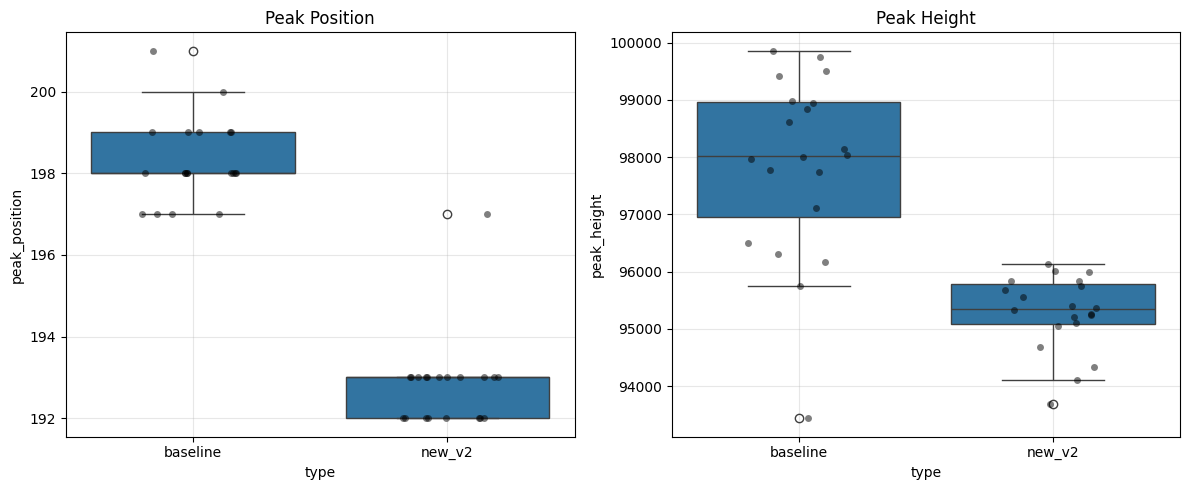

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# загрузка данных
baseline_df = pd.read_csv("experiment_results/peak_results_main_real_spb.csv")
new_df = pd.read_csv("experiment_results/new_v2_results_20260420_151850.csv")

baseline = baseline_df[baseline_df["type"] == "baseline"].copy()
new_v2 = new_df.copy()

# объединяем
plot_df = pd.concat([baseline, new_v2], ignore_index=True)


# ============================================
# FIGURE
# ============================================

plt.figure(figsize=(12, 5))

# --------------------------------------------
# Peak Position
# --------------------------------------------
plt.subplot(1, 2, 1)
sns.boxplot(data=plot_df, x="type", y="peak_position")
sns.stripplot(data=plot_df, x="type", y="peak_position",
              color="black", alpha=0.5, jitter=0.2)

plt.title("Peak Position")
plt.grid(True, alpha=0.3)


# --------------------------------------------
# Peak Height
# --------------------------------------------
plt.subplot(1, 2, 2)
sns.boxplot(data=plot_df, x="type", y="peak_height")
sns.stripplot(data=plot_df, x="type", y="peak_height",
              color="black", alpha=0.5, jitter=0.2)

plt.title("Peak Height")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()